<a href="https://colab.research.google.com/github/irungugraceig-sudo/4d-perception-engine/blob/main/Energy_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# ENERGY DATA ANALYSIS - New England Energy Consumption
# Grace Irungu - Northeastern University
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load the energy data
df = pd.read_csv('/content/drive/MyDrive/Machine Learning lab/energy_patterns.csv')

df = df.drop('Unnamed: 4', axis=1)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.set_index('Date').sort_index()

print("Data loaded successfully")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully
Date range: 2006-01-01 00:00:00 to 2017-12-31 00:00:00
Total records: 4383


In [ ]:
print("\n" + "="*70)
print("Data Quality Assessment")
print("="*70)

# Missing data summary
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print("\nMissing Data Summary:")
print(missing_summary)

# Data availability timeline
print("\nData Availability Timeline:")
for col in ['Consumption', 'Wind', 'Solar']:
    first_valid_idx = df[col].first_valid_index()
    if first_valid_idx:
        print(f"{col}: Starts {first_valid_idx.date()}")


Data Quality Assessment

Missing Data Summary:
                      Missing_Count  Missing_Percentage
Consumption                       0                0.00
Wind                           1463               33.38
Solar                          2195               50.08
Year                              0                0.00
Month                             0                0.00
DayOfWeek                         0                0.00
DayName                           0                0.00
Total_Renewable                   0                0.00
Renewable_Percentage              0                0.00

Data Availability Timeline:
Consumption: Starts 2006-01-01
Wind: Starts 2010-01-01
Solar: Starts 2012-01-01


In [ ]:
df_copy = df.copy()

EXPLORATORY VISUALIZATION


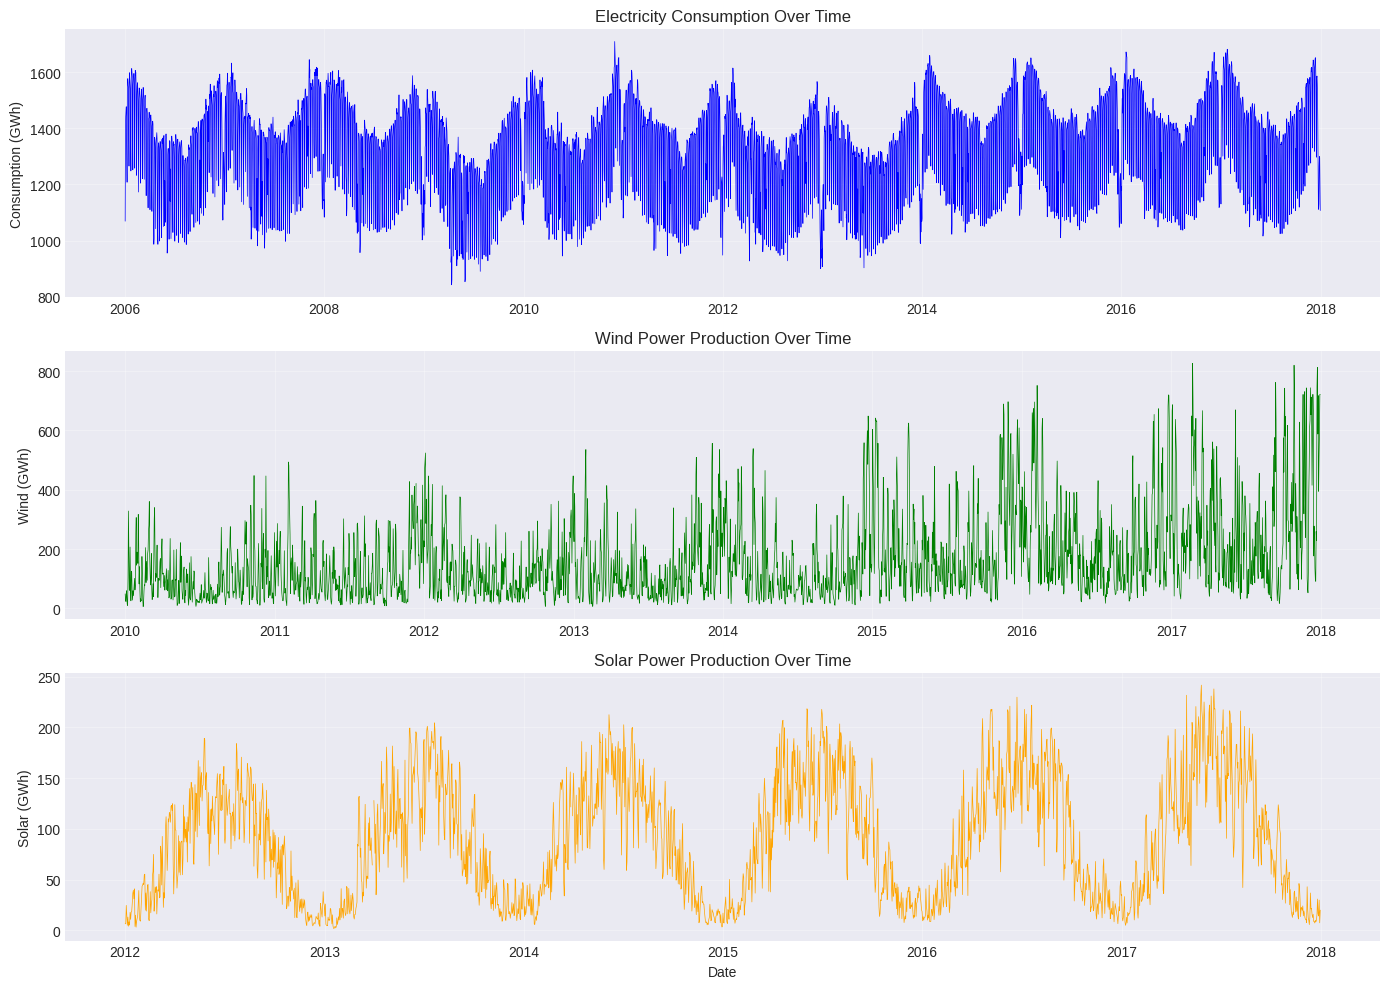

In [ ]:
print ("EXPLORATORY VISUALIZATION")
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Consumption'], color='blue', linewidth=0.5)
axes[0].set_ylabel('Consumption (GWh)')
axes[0].set_title('Electricity Consumption Over Time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['Wind'], color='green', linewidth=0.5)
axes[1].set_ylabel('Wind (GWh)')
axes[1].set_title('Wind Power Production Over Time')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['Solar'], color='orange', linewidth=0.5)
axes[2].set_ylabel('Solar (GWh)')
axes[2].set_title('Solar Power Production Over Time')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("QUESTION A: Temporal Patterns of Energy Consumption")
print("="*70)

# Extract time features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek
df['DayName'] = df.index.day_name()

# Maximum consumption
max_consumption = df['Consumption'].max()
max_date = df['Consumption'].idxmax()
print(f"\nMaximum Consumption: {max_consumption:.2f} GWh on {max_date.date()} ({max_date.day_name()})")

# Minimum consumption
min_consumption = df['Consumption'].min()
min_date = df['Consumption'].idxmin()
print(f"Minimum Consumption: {min_consumption:.2f} GWh on {min_date.date()} ({min_date.day_name()})")

# Monthly patterns
print("\nAverage Consumption by Month:")
monthly_avg = df.groupby('Month')['Consumption'].mean().sort_values(ascending=False)
for month, value in monthly_avg.items():
    month_name = pd.Timestamp(2020, month, 1).month_name()
    print(f"  {month_name:12s}: {value:.2f} GWh")

# Weekly patterns
print("\nAverage Consumption by Day of Week:")
daily_avg = df.groupby('DayName')['Consumption'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for day in day_order:
    print(f"  {day:12s}: {daily_avg[day]:.2f} GWh")



QUESTION A: Temporal Patterns of Energy Consumption

Maximum Consumption: 1709.57 GWh on 2010-12-01 (Wednesday)
Minimum Consumption: 842.39 GWh on 2009-04-12 (Sunday)

Average Consumption by Month:
  February    : 1452.46 GWh
  January     : 1433.78 GWh
  November    : 1425.19 GWh
  March       : 1380.69 GWh
  December    : 1374.36 GWh
  October     : 1351.41 GWh
  September   : 1314.35 GWh
  April       : 1298.46 GWh
  July        : 1266.70 GWh
  June        : 1263.17 GWh
  May         : 1261.91 GWh
  August      : 1249.99 GWh

Average Consumption by Day of Week:
  Monday      : 1389.79 GWh
  Tuesday     : 1428.28 GWh
  Wednesday   : 1433.61 GWh
  Thursday    : 1421.16 GWh
  Friday      : 1394.62 GWh
  Saturday    : 1200.55 GWh
  Sunday      : 1103.10 GWh



QUESTION B: Wind & Solar Variation Throughout the Year

Wind Power by Month (Average GWh):
  December    : 277.57 GWh
  January     : 207.72 GWh
  February    : 206.94 GWh
  November    : 198.93 GWh
  March       : 174.22 GWh
  October     : 172.31 GWh
  April       : 148.64 GWh
  May         : 129.16 GWh
  September   : 127.73 GWh
  June        : 114.81 GWh
  July        : 112.38 GWh
  August      : 109.35 GWh

Solar Power by Month (Average GWh):
  June        : 152.57 GWh
  July        : 150.75 GWh
  May         : 139.97 GWh
  August      : 138.78 GWh
  April       : 119.73 GWh
  September   : 103.25 GWh
  March       : 88.04 GWh
  October     : 61.33 GWh
  February    : 43.85 GWh
  November    : 30.87 GWh
  December    : 20.07 GWh
  January     : 19.57 GWh


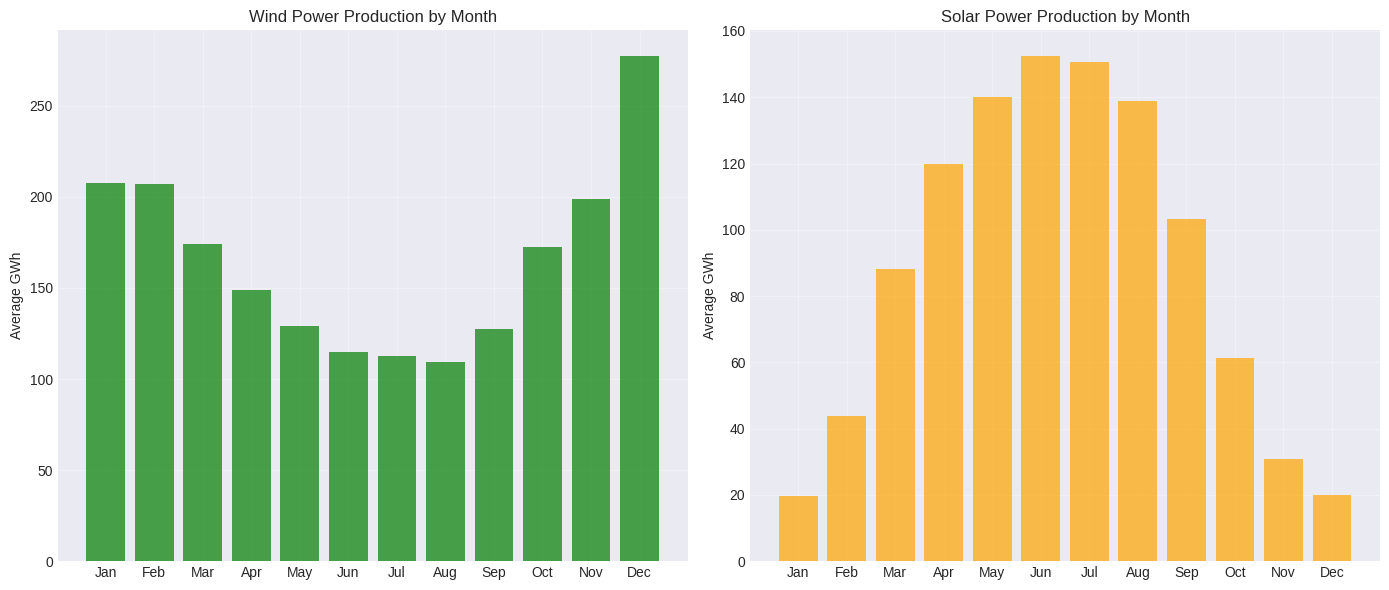


QUESTION C: Long-Term Trends in the Data

Yearly Averages:
      Consumption    Wind  Solar
Year                            
2006      1339.91     NaN    NaN
2007      1360.64     NaN    NaN
2008      1354.02     NaN    NaN
2009      1259.55     NaN    NaN
2010      1338.60   98.39    NaN
2011      1328.26  120.97    NaN
2012      1282.99  125.31  76.19
2013      1269.42  129.31  81.43
2014      1381.27  140.41  89.53
2015      1384.29  212.24  95.64
2016      1382.32  210.40  94.43
2017      1382.84  281.28  98.31

Growth Analysis (First Year to Last Year):

Consumption:
  2006: 1339.91 GWh
  2017: 1382.84 GWh
  Growth: +3.2%

Wind:
  2010: 98.39 GWh
  2017: 281.28 GWh
  Growth: +185.9%

Solar:
  2012: 76.19 GWh
  2017: 98.31 GWh
  Growth: +29.0%


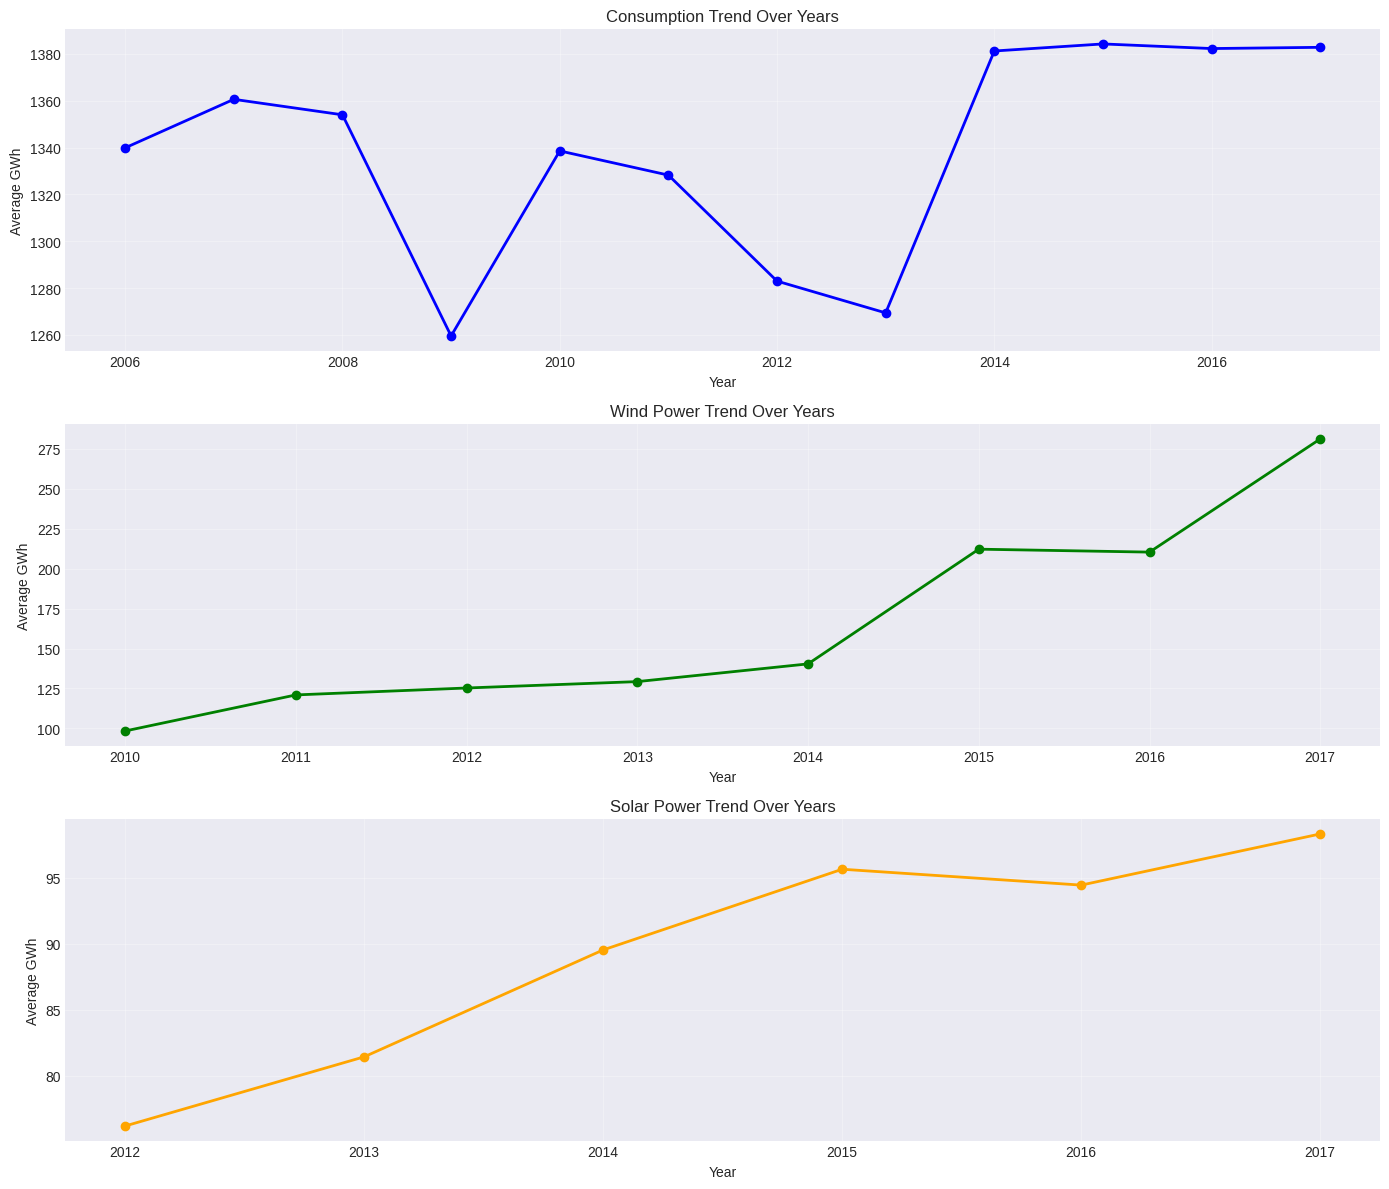

In [ ]:
print("\n" + "="*70)
print("QUESTION C: Long-Term Trends in the Data")
print("="*70)

# Yearly averages
yearly_stats = df.groupby('Year')[['Consumption', 'Wind', 'Solar']].mean()

print("\nYearly Averages:")
print(yearly_stats.round(2))

# Growth analysis
print("\nGrowth Analysis (First Year to Last Year):")
for col in ['Consumption', 'Wind', 'Solar']:
    first_year = yearly_stats[col].first_valid_index()
    last_year = yearly_stats[col].last_valid_index()
    first_val = yearly_stats.loc[first_year, col]
    last_val = yearly_stats.loc[last_year, col]

    if pd.notna(first_val) and pd.notna(last_val):
        growth = ((last_val - first_val) / first_val) * 100
        print(f"\n{col}:")
        print(f"  {first_year}: {first_val:.2f} GWh")
        print(f"  {last_year}: {last_val:.2f} GWh")
        print(f"  Growth: {growth:+.1f}%")

# Trend visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

yearly_stats['Consumption'].plot(ax=axes[0], marker='o', color='blue', linewidth=2)
axes[0].set_title('Consumption Trend Over Years')
axes[0].set_ylabel('Average GWh')
axes[0].grid(True, alpha=0.3)

yearly_stats['Wind'].plot(ax=axes[1], marker='o', color='green', linewidth=2)
axes[1].set_title('Wind Power Trend Over Years')
axes[1].set_ylabel('Average GWh')
axes[1].grid(True, alpha=0.3)

yearly_stats['Solar'].plot(ax=axes[2], marker='o', color='orange', linewidth=2)
axes[2].set_title('Solar Power Trend Over Years')
axes[2].set_ylabel('Average GWh')
axes[2].set_xlabel('Year')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



QUESTION D: Wind & Solar Contribution to Demand

Yearly Renewable Contribution:
      Consumption    Wind  Solar  Renewable_Percentage
Year                                                  
2006      1339.91     NaN    NaN                  0.00
2007      1360.64     NaN    NaN                  0.00
2008      1354.02     NaN    NaN                  0.00
2009      1259.55     NaN    NaN                  0.00
2010      1338.60   98.39    NaN                  7.31
2011      1328.26  120.97    NaN                  9.17
2012      1282.99  125.31  76.19                 16.19
2013      1269.42  129.31  81.43                 16.97
2014      1381.27  140.41  89.53                 16.87
2015      1384.29  212.24  95.64                 22.62
2016      1382.32  210.40  94.43                 22.44
2017      1382.84  281.28  98.31                 27.88

Renewable Percentage Change Over Time:
  2010: 7.3%
  2017: 27.9%
  Total Growth: +20.6 percentage points


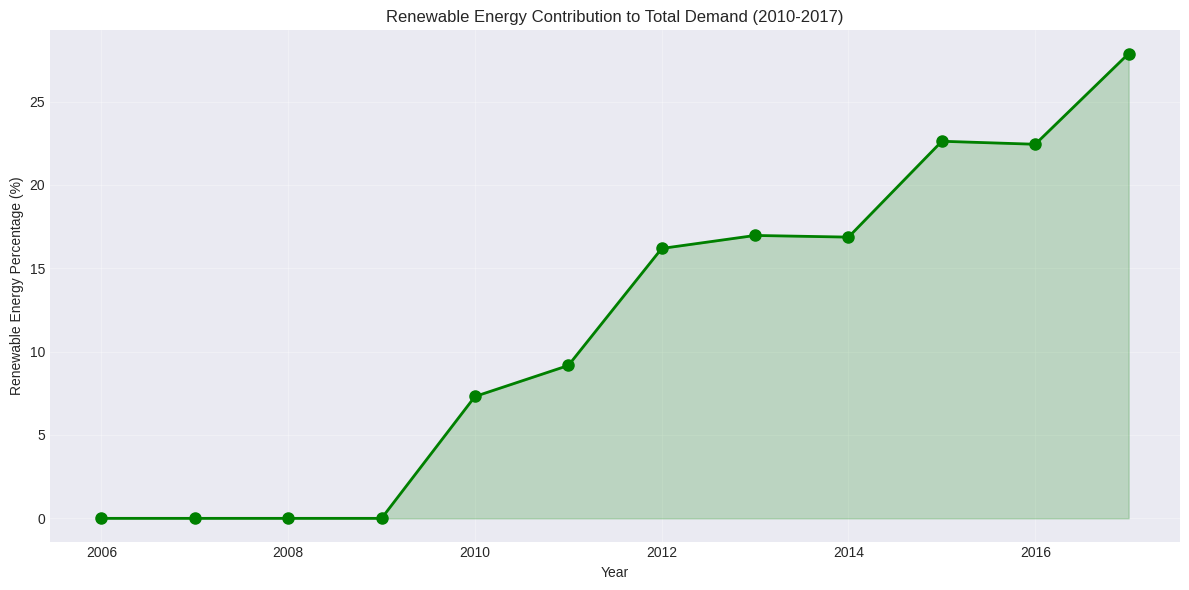


Conclusion:
Renewable energy contribution increased from approximately 7-8% in 2010
to 27-28% in 2017, demonstrating significant growth in clean energy adoption.


In [ ]:
print("\n" + "="*70)
print("QUESTION D: Wind & Solar Contribution to Demand")
print("="*70)

# Calculate renewable contribution
df['Total_Renewable'] = df['Wind'].fillna(0) + df['Solar'].fillna(0)
df['Renewable_Percentage'] = (df['Total_Renewable'] / df['Consumption']) * 100

# Yearly contribution
yearly_contribution = df.groupby('Year').agg({
    'Consumption': 'mean',
    'Wind': 'mean',
    'Solar': 'mean',
    'Renewable_Percentage': 'mean'
}).round(2)

print("\nYearly Renewable Contribution:")
print(yearly_contribution)

# Trend analysis
print("\nRenewable Percentage Change Over Time:")
print(f"  2010: {yearly_contribution.loc[2010, 'Renewable_Percentage']:.1f}%")
print(f"  2017: {yearly_contribution.loc[2017, 'Renewable_Percentage']:.1f}%")

growth = yearly_contribution.loc[2017, 'Renewable_Percentage'] - yearly_contribution.loc[2010, 'Renewable_Percentage']
print(f"  Total Growth: +{growth:.1f} percentage points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(yearly_contribution.index, yearly_contribution['Renewable_Percentage'],
        marker='o', linewidth=2, markersize=8, color='green')
ax.fill_between(yearly_contribution.index, yearly_contribution['Renewable_Percentage'],
                alpha=0.2, color='green')
ax.set_xlabel('Year')
ax.set_ylabel('Renewable Energy Percentage (%)')
ax.set_title('Renewable Energy Contribution to Total Demand (2010-2017)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConclusion:")
print("Renewable energy contribution increased from approximately 7-8% in 2010")
print("to 27-28% in 2017, demonstrating significant growth in clean energy adoption.")

In [ ]:
# ============================================================================
# ADDITIONAL SECTION: RENEWABLE VS TOTAL ENERGY COMPARISON
# ============================================================================

print("\n" + "="*70)
print("RENEWABLE VS TOTAL ENERGY COMPARISON")
print("="*70)

# Calculate renewable and non-renewable energy
df['Total_Renewable'] = df['Wind'].fillna(0) + df['Solar'].fillna(0)
df['Non_Renewable'] = df['Consumption'] - df['Total_Renewable']
df['Renewable_Percentage'] = (df['Total_Renewable'] / df['Consumption']) * 100

# Yearly comparison
yearly_comparison = df.groupby('Year').agg({
    'Consumption': 'mean',
    'Total_Renewable': 'mean',
    'Non_Renewable': 'mean',
    'Wind': 'mean',
    'Solar': 'mean',
    'Renewable_Percentage': 'mean'
}).round(2)

print("\nYearly Energy Mix (Average GWh):")
print(yearly_comparison)

# Summary statistics
print("\n" + "="*70)
print("Energy Mix Summary Statistics")
print("="*70)

for year in [2010, 2012, 2015, 2017]:
    if year in yearly_comparison.index:
        total = yearly_comparison.loc[year, 'Consumption']
        renewable = yearly_comparison.loc[year, 'Total_Renewable']
        non_renewable = yearly_comparison.loc[year, 'Non_Renewable']
        renewable_pct = yearly_comparison.loc[year, 'Renewable_Percentage']

        print(f"\n{year}:")
        print(f"  Total Consumption:    {total:.2f} GWh")
        print(f"  Renewable Energy:     {renewable:.2f} GWh ({renewable_pct:.1f}%)")
        print(f"  Non-Renewable Energy: {non_renewable:.2f} GWh ({100-renewable_pct:.1f}%)")
        print(f"    - Wind:             {yearly_comparison.loc[year, 'Wind']:.2f} GWh")
        print(f"    - Solar:            {yearly_comparison.loc[year, 'Solar']:.2f} GWh")



RENEWABLE VS TOTAL ENERGY COMPARISON

Yearly Energy Mix (Average GWh):
      Consumption  Total_Renewable  Non_Renewable    Wind  Solar  \
Year                                                               
2006      1339.91             0.00        1339.91     NaN    NaN   
2007      1360.64             0.00        1360.64     NaN    NaN   
2008      1354.02             0.00        1354.02     NaN    NaN   
2009      1259.55             0.00        1259.55     NaN    NaN   
2010      1338.60            98.39        1240.21   98.39    NaN   
2011      1328.26           120.64        1207.62  120.97    NaN   
2012      1282.99           201.50        1081.49  125.31  76.19   
2013      1269.42           210.29        1059.12  129.31  81.43   
2014      1381.27           229.06        1152.22  140.41  89.53   
2015      1384.29           307.88        1076.41  212.24  95.64   
2016      1382.32           304.84        1077.48  210.40  94.43   
2017      1382.84           379.59        10

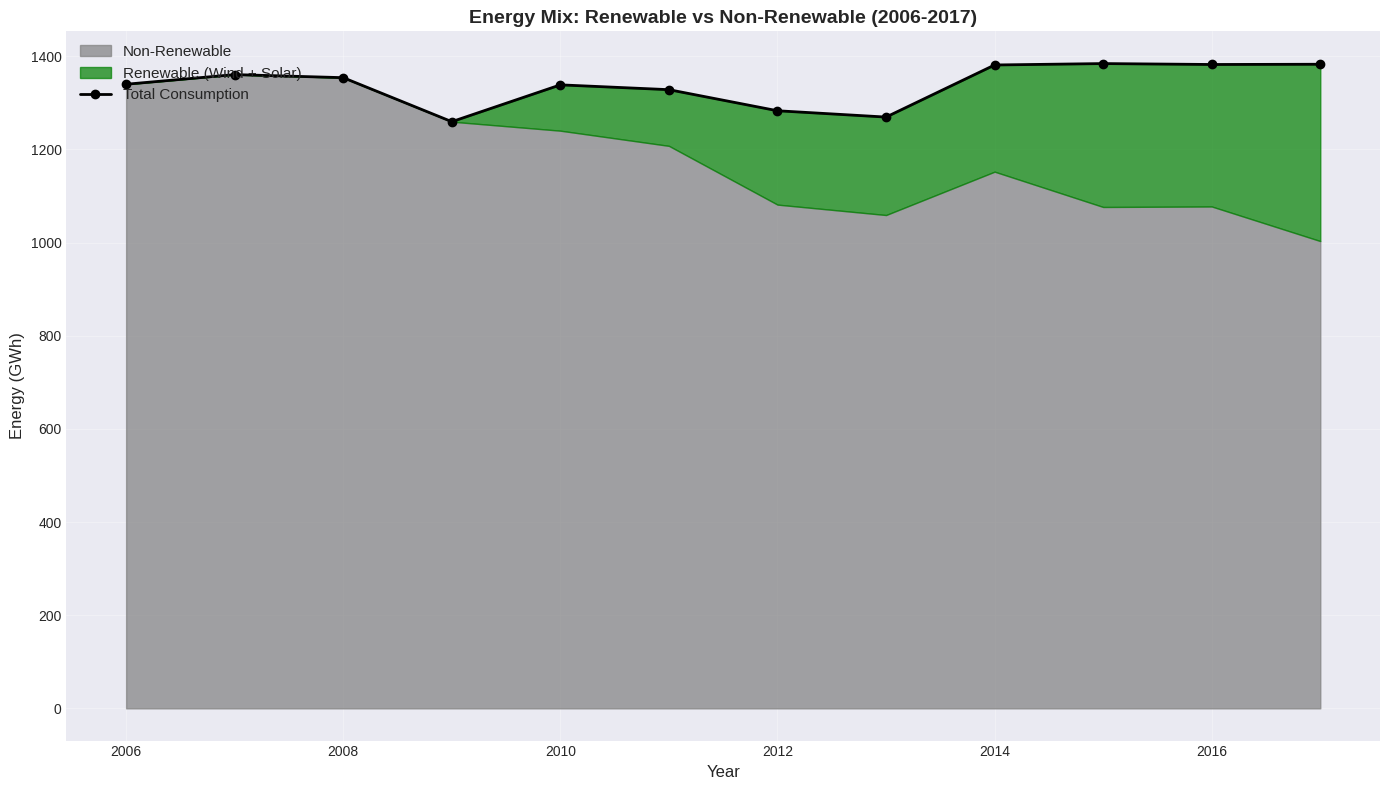

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create stacked area chart
ax.fill_between(yearly_comparison.index, 0, yearly_comparison['Non_Renewable'],
                label='Non-Renewable', alpha=0.7, color='gray')
ax.fill_between(yearly_comparison.index, yearly_comparison['Non_Renewable'],
                yearly_comparison['Consumption'],
                label='Renewable (Wind + Solar)', alpha=0.7, color='green')

ax.plot(yearly_comparison.index, yearly_comparison['Consumption'],
        color='black', linewidth=2, label='Total Consumption', marker='o')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Energy (GWh)', fontsize=12)
ax.set_title('Energy Mix: Renewable vs Non-Renewable (2006-2017)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

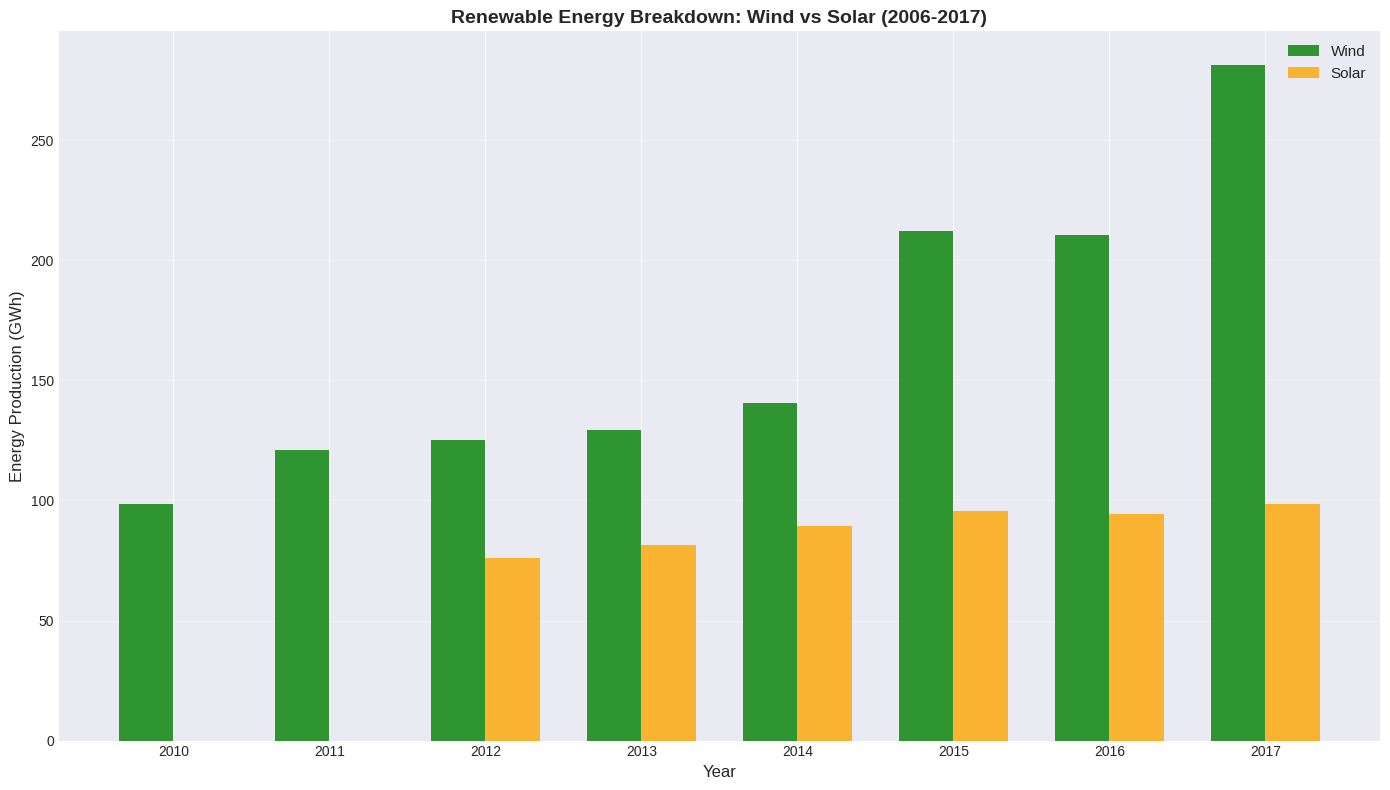

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

x = yearly_comparison.index
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, yearly_comparison['Wind'], width,
               label='Wind', color='green', alpha=0.8)
bars2 = ax.bar(x + width/2, yearly_comparison['Solar'], width,
               label='Solar', color='orange', alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Energy Production (GWh)', fontsize=12)
ax.set_title('Renewable Energy Breakdown: Wind vs Solar (2006-2017)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()